In [10]:
# Cell 1: Import Libraries
# ====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings for clean output
warnings.filterwarnings('ignore')

# sklearn libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score
)

# CatBoost library (optional, برای مدل‌های پیشرفته)
from catboost import CatBoostClassifier

# Initial plotting settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [11]:
# Cell 2: Load Dataset
# ====================================================
df = pd.read_csv("Telco-Customer-Churn.csv")

print("📊 Dataset Overview:")
print("=" * 50)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Column names: {list(df.columns)}")

# First 5 rows
print("\n🔍 First 5 rows of dataset:")
print("=" * 50)
print(df.head())

# Statistical summary of numerical columns
print("\n📈 Statistical summary of numerical columns:")
print("=" * 50)
print(df.describe())

# Check for missing values
print("\n⚠️ Checking for missing values:")
print("=" * 50)
null_info = df.isnull().sum()
print(null_info[null_info > 0] if null_info.sum() > 0 else "✅ No null values found")

# Data types
print("\n🔧 Data types:")
print("=" * 50)
print(df.dtypes.value_counts())

📊 Dataset Overview:
Number of rows: 7043
Number of columns: 21
Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

🔍 First 5 rows of dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone se

In [12]:
# Cell 3: Data Cleaning & Preprocessing
# ====================================================
print("🧹 Starting data cleaning process...")
print("=" * 50)

# 1. Convert TotalCharges to numeric
original_shape = df.shape
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"1. TotalCharges column converted to numeric.")

# 2. Remove null values if any
null_count = df['TotalCharges'].isnull().sum()
if null_count > 0:
    print(f"   ⚠️ Found {null_count} null values in TotalCharges.")
    df.dropna(inplace=True)
    print(f"   ✅ Null values removed.")
else:
    print(f"   ✅ No null values found.")

print(f"   Data volume changes: {original_shape[0]} → {df.shape[0]} rows")

# 3. Convert target variable to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("2. Churn variable converted to numeric: Yes=1, No=0")

# 4. Remove customerID column
df.drop('customerID', axis=1, inplace=True)
print("3. customerID column removed")

# 5. Check class distribution
print("\n📊 Final class distribution:")
print("=" * 50)
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

for value, count, percent in zip(churn_counts.index, churn_counts.values, churn_percent.values):
    label = "Churn" if value == 1 else "No Churn"
    print(f"{label}: {count} samples ({percent:.1f}%)")

print(f"\n📈 Class ratio: 1:{churn_counts[0]/churn_counts[1]:.1f}")
print("⚠️ Note: Dataset is imbalanced (minority class less than 30%)")

🧹 Starting data cleaning process...
1. TotalCharges column converted to numeric.
   ⚠️ Found 11 null values in TotalCharges.
   ✅ Null values removed.
   Data volume changes: 7043 → 7032 rows
2. Churn variable converted to numeric: Yes=1, No=0
3. customerID column removed

📊 Final class distribution:
No Churn: 5163 samples (73.4%)
Churn: 1869 samples (26.6%)

📈 Class ratio: 1:2.8
⚠️ Note: Dataset is imbalanced (minority class less than 30%)


🔬 Exploratory Data Analysis (EDA)


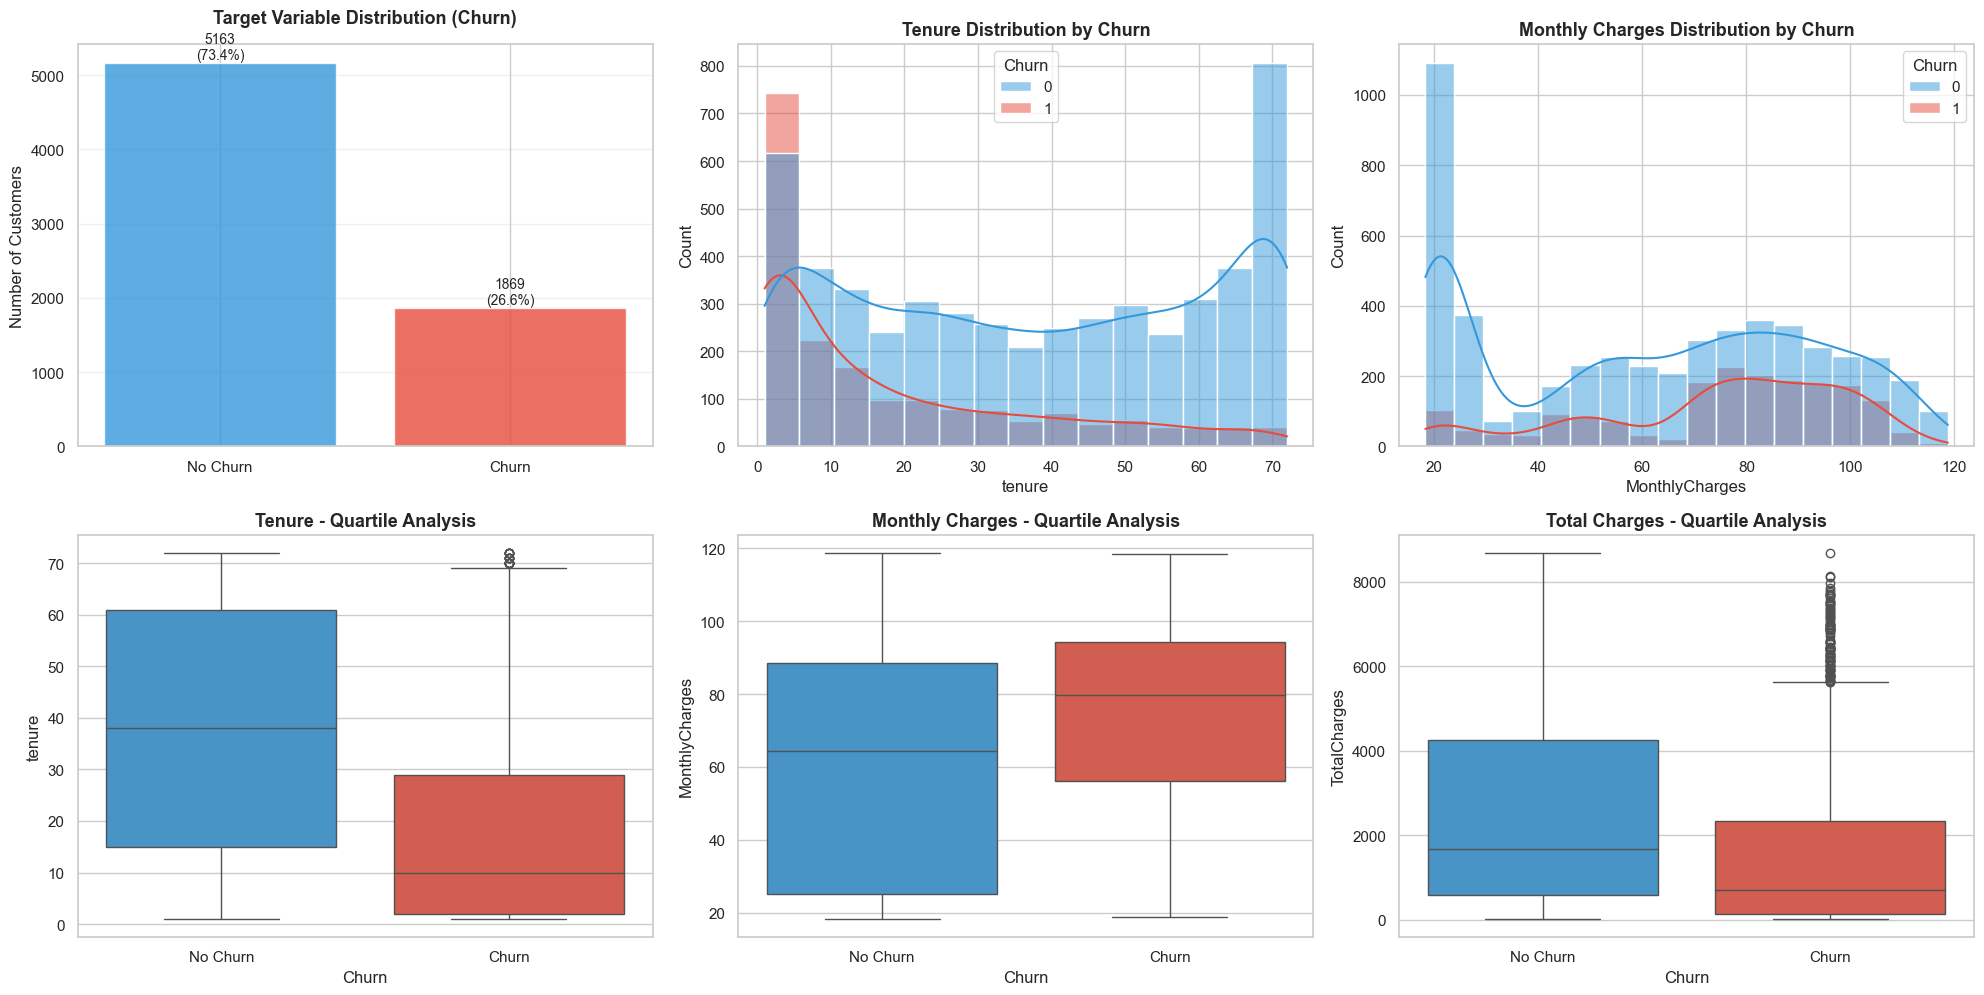

In [13]:
# Cell 4: Exploratory Data Analysis - Part 1
# ====================================================
print("🔬 Exploratory Data Analysis (EDA)")
print("=" * 50)

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.subplots_adjust(hspace=0.6, wspace=0.4)

colors = ['#3498db', '#e74c3c']
churn_labels = ['No Churn', 'Churn']
churn_counts = df['Churn'].value_counts()

# Target variable distribution
ax1 = axes[0, 0]
bars = ax1.bar(churn_labels, churn_counts, color=colors, alpha=0.8)
ax1.set_title('Target Variable Distribution (Churn)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Number of Customers')
ax1.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, churn_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10)

# Tenure distribution
ax2 = axes[0, 1]
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=ax2, palette=colors)
ax2.set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')

# MonthlyCharges distribution
ax3 = axes[0, 2]
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=ax3, palette=colors)
ax3.set_title('Monthly Charges Distribution by Churn', fontsize=13, fontweight='bold')

# Boxplots
ax4 = axes[1, 0]
sns.boxplot(data=df, x='Churn', y='tenure', ax=ax4, palette=colors)
ax4.set_title('Tenure - Quartile Analysis', fontsize=13, fontweight='bold')
ax4.set_xticklabels(['No Churn', 'Churn'])

ax5 = axes[1, 1]
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax5, palette=colors)
ax5.set_title('Monthly Charges - Quartile Analysis', fontsize=13, fontweight='bold')
ax5.set_xticklabels(['No Churn', 'Churn'])

ax6 = axes[1, 2]
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=ax6, palette=colors)
ax6.set_title('Total Charges - Quartile Analysis', fontsize=13, fontweight='bold')
ax6.set_xticklabels(['No Churn', 'Churn'])

# Remove empty subplots
axes[2, 0].remove()
axes[2, 1].remove()
axes[2, 2].remove()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

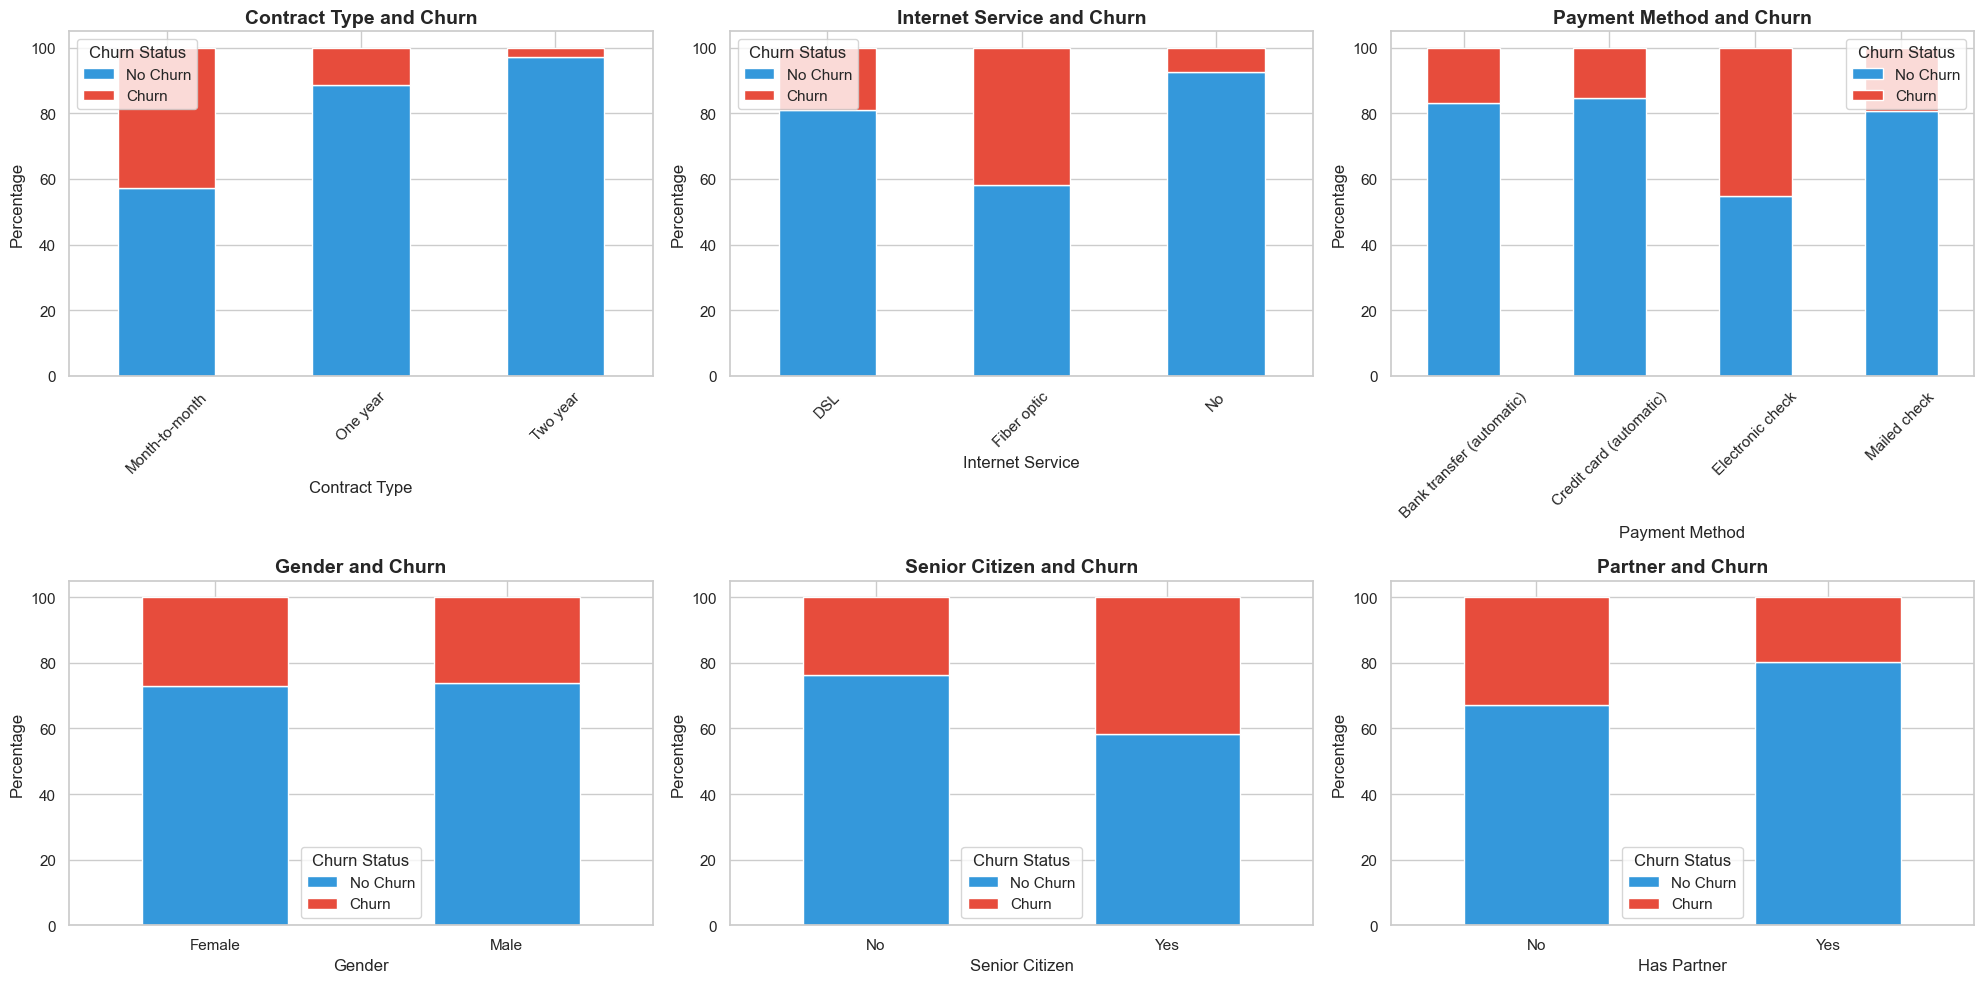

In [14]:
# Cell 5: EDA - Categorical Features
# ====================================================
fig2 = plt.figure(figsize=(20, 10))

# Contract vs Churn
ax1 = plt.subplot(2, 3, 1)
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn_percent = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100
contract_churn_percent.plot(kind='bar', stacked=True, ax=ax1, color=['#3498db', '#e74c3c'])
ax1.set_title('Contract Type and Churn', fontsize=14, fontweight='bold')
ax1.set_xlabel('Contract Type')
ax1.set_ylabel('Percentage')
ax1.legend(['No Churn', 'Churn'], title='Churn Status')
ax1.tick_params(axis='x', rotation=45)

# InternetService vs Churn
ax2 = plt.subplot(2, 3, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
internet_churn_percent = internet_churn.div(internet_churn.sum(axis=1), axis=0) * 100
internet_churn_percent.plot(kind='bar', stacked=True, ax=ax2, color=['#3498db', '#e74c3c'])
ax2.set_title('Internet Service and Churn', fontsize=14, fontweight='bold')
ax2.set_xlabel('Internet Service')
ax2.set_ylabel('Percentage')
ax2.legend(['No Churn', 'Churn'], title='Churn Status')
ax2.tick_params(axis='x', rotation=45)

# PaymentMethod vs Churn
ax3 = plt.subplot(2, 3, 3)
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'])
payment_churn_percent = payment_churn.div(payment_churn.sum(axis=1), axis=0) * 100
payment_churn_percent.plot(kind='bar', stacked=True, ax=ax3, color=['#3498db', '#e74c3c'])
ax3.set_title('Payment Method and Churn', fontsize=14, fontweight='bold')
ax3.set_xlabel('Payment Method')
ax3.set_ylabel('Percentage')
ax3.legend(['No Churn', 'Churn'], title='Churn Status')
ax3.tick_params(axis='x', rotation=45)

# Gender vs Churn
ax4 = plt.subplot(2, 3, 4)
gender_churn = pd.crosstab(df['gender'], df['Churn'])
gender_churn_percent = gender_churn.div(gender_churn.sum(axis=1), axis=0) * 100
gender_churn_percent.plot(kind='bar', stacked=True, ax=ax4, color=['#3498db', '#e74c3c'])
ax4.set_title('Gender and Churn', fontsize=14, fontweight='bold')
ax4.set_xlabel('Gender')
ax4.set_ylabel('Percentage')
ax4.legend(['No Churn', 'Churn'], title='Churn Status')
ax4.tick_params(axis='x', rotation=0)

# SeniorCitizen vs Churn
ax5 = plt.subplot(2, 3, 5)
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'])
senior_churn_percent = senior_churn.div(senior_churn.sum(axis=1), axis=0) * 100
senior_churn_percent.plot(kind='bar', stacked=True, ax=ax5, color=['#3498db', '#e74c3c'])
ax5.set_title('Senior Citizen and Churn', fontsize=14, fontweight='bold')
ax5.set_xlabel('Senior Citizen')
ax5.set_ylabel('Percentage')
ax5.legend(['No Churn', 'Churn'], title='Churn Status')
ax5.set_xticklabels(['No', 'Yes'], rotation=0)

# Partner vs Churn
ax6 = plt.subplot(2, 3, 6)
partner_churn = pd.crosstab(df['Partner'], df['Churn'])
partner_churn_percent = partner_churn.div(partner_churn.sum(axis=1), axis=0) * 100
partner_churn_percent.plot(kind='bar', stacked=True, ax=ax6, color=['#3498db', '#e74c3c'])
ax6.set_title('Partner and Churn', fontsize=14, fontweight='bold')
ax6.set_xlabel('Has Partner')
ax6.set_ylabel('Percentage')
ax6.legend(['No Churn', 'Churn'], title='Churn Status')
ax6.set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.show()

In [15]:
# Cell 6: Feature/Target Split & Data Preparation
# ====================================================
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Identify categorical and numerical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n🔤 Categorical features ({len(cat_features)}): {cat_features}")
print(f"\n🔢 Numerical features ({len(num_features)}): {num_features}")

Features (X): (7032, 19)
Target (y): (7032,)

🔤 Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

🔢 Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [16]:
# Cell 7: Train/Test Split
# ====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape}, Test Set: {X_test.shape}")
print(f"Class distribution - Train: {y_train.value_counts().to_dict()}, Test: {y_test.value_counts().to_dict()}")

Training Set: (5625, 19), Test Set: (1407, 19)
Class distribution - Train: {0: 4130, 1: 1495}, Test: {0: 1033, 1: 374}


In [19]:
# Cell 8: Data Preparation for Logistic Regression
# ====================================================
# One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

feature_names = X_train_encoded.columns.tolist()

print("✅ Data prepared for Logistic Regression")

✅ Data prepared for Logistic Regression


In [20]:
# Cell 9: Baseline Model - Logistic Regression
# ====================================================
baseline_model = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs'
)

import time
start_time = time.time()
baseline_model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"Model trained in {training_time:.2f} seconds")

# Predictions
y_pred_base = baseline_model.predict(X_test_scaled)
y_proba_base = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred_base)
roc_auc = roc_auc_score(y_test, y_proba_base)
f1 = f1_score(y_test, y_pred_base)

print(f"Accuracy: {accuracy:.4f}, ROC-AUC: {roc_auc:.4f}, F1-Score: {f1:.4f}")

# Cross-Validation
cv_scores = cross_val_score(
    baseline_model,
    X_train_scaled,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
print(f"CV Mean ROC-AUC: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")

# Coefficient analysis
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': baseline_model.coef_[0],
    'Abs_Coefficient': np.abs(baseline_model.coef_[0])
})

print("\nTop 10 features increasing Churn:")
print(coefficients.sort_values('Coefficient', ascending=False).head(10)[['Feature', 'Coefficient']])

print("\nTop 10 features decreasing Churn:")
print(coefficients.sort_values('Coefficient', ascending=True).head(10)[['Feature', 'Coefficient']])

Model trained in 0.01 seconds
Accuracy: 0.7264, ROC-AUC: 0.8350, F1-Score: 0.6075
CV Mean ROC-AUC: 0.8460, Std: 0.0054

Top 10 features increasing Churn:
                                  Feature  Coefficient
10            InternetService_Fiber optic     0.746144
3                            TotalCharges     0.623279
21                        StreamingTV_Yes     0.259691
23                    StreamingMovies_Yes     0.252870
9                       MultipleLines_Yes     0.202763
28         PaymentMethod_Electronic check     0.193697
26                   PaperlessBilling_Yes     0.124250
0                           SeniorCitizen     0.075306
17                   DeviceProtection_Yes     0.069476
27  PaymentMethod_Credit card (automatic)     0.029226

Top 10 features decreasing Churn:
                                 Feature  Coefficient
1                                 tenure    -1.263854
2                         MonthlyCharges    -0.928682
25                     Contract_Two year    